# 6.2 Comparing $g_k$ and $PPI_k$ in a Clean 2x2 Study

This notebook is written for publication-ready clarity with two factors:

- **Setup**: `game_only` vs `with_pregame`
- **Context**: `neutral` vs `emotional`

So the design has 4 cells:
1. game_only + neutral (baseline)
2. game_only + emotional
3. with_pregame + neutral
4. with_pregame + emotional

This notebook handles currently missing runs gracefully and updates automatically when new files are added.

## Research Questions and Hypotheses

**RQ1**: Do agents show empathic behavior in a shared-resource environment?

**RQ2**: Do social interaction (pregame discussion) and emotional context influence these behaviors?

We test:
- Main effect of context (neutral vs emotional)
- Main effect of setup (game_only vs with_pregame)
- Interaction effect (whether emotional impact depends on setup)

## Import Libraries

**What this does**: imports plotting and statistics libraries.

**Why needed**: all downstream analysis depends on these modules.

**Result / interpretation**: successful execution means your environment is ready.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from itertools import combinations
import importlib
import analysis_utils

# Scipy functions for various statistical tests
from scipy.stats import (
    ttest_rel, ttest_1samp, fisher_exact, mannwhitneyu,
    shapiro, levene, f_oneway, kruskal, tukey_hsd,
)

# Ensure latest utility module code is loaded in notebook sessions.
importlib.reload(analysis_utils)

# Utility module - all helper/statistics functions live there
from analysis_utils import (
    decision_text, build_effect_row,
    cramers_v, kruskal_epsilon_squared, anova_eta_squared,
    group_sd, cohens_d_independent, format_p,
    spearman_summary, build_gini_row,
    holm_adjust, p_stars,
    load_run_data, load_gini_scores,
    build_reference_vs_model_table,
)

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)

print('Libraries imported successfully.')

Libraries imported successfully.


## Resolve Paths and Data Sources

**What this does**: builds absolute paths to both data sources (`game_only`, `with_pregame`).

**Why needed**: avoids path errors and keeps code portable between machines.

**Result / interpretation**: path existence checks should be `True` for runs folders you want analyzed.

In [2]:
BASE = Path.cwd().resolve()
if not (BASE / 'backend').exists() and (BASE.parent / 'backend').exists():
    BASE = BASE.parent

DATA_ROOT = BASE / 'backend' / 'data'

RUN_SOURCES = {
    'game_only':    DATA_ROOT / 'game_only'    / 'runs',
    'with_pregame': DATA_ROOT / 'with_pregame' / 'runs',
}

SCORE_SOURCES = {
    'game_only':    DATA_ROOT / 'game_only'    / 'scores',
    'with_pregame': DATA_ROOT / 'with_pregame' / 'scores',
}

SETUP_NO_INTERACTION = 'No interaction'
SETUP_WITH_INTERACTION = 'With interaction'
COND_NEUTRAL = 'Neutral'
COND_EMOTION = 'Emotion'

setup_label_map = {
    'game_only': SETUP_NO_INTERACTION,
    'with_pregame': SETUP_WITH_INTERACTION,
}
condition_label_map = {
    'neutral': COND_NEUTRAL,
    'emotional': COND_EMOTION,
}
setup_order = ['game_only', 'with_pregame']
condition_order = ['neutral', 'emotional']
setup_display_order = [setup_label_map[value] for value in setup_order]
condition_display_order = [condition_label_map[value] for value in condition_order]

# Human-readable labels used in plots and Gini loading
model_label_map = {
    'claude-haiku-4-5-20251001': 'Claude-Haiku-4.5',
    'gemini-3-flash-preview':    'Gemini-3-Flash',
    'gpt-5-mini':                'GPT-5-mini',
    'grok-3-mini-fast-beta':     'Grok-3-mini',
}

alpha = 0.05
ARTIFACTS_DIR = BASE / 'data_evaluation' / 'artifacts'

print('Base:', BASE)
print('Artifacts directory:', ARTIFACTS_DIR)
for setup, p in RUN_SOURCES.items():
    print(f'{setup_label_map[setup]}: exists={p.exists()} path={p}')

Base: /Users/fanambyrandriamahenintsoa/Personal/Study/simCo
Artifacts directory: /Users/fanambyrandriamahenintsoa/Personal/Study/simCo/data_evaluation/artifacts
No interaction: exists=True path=/Users/fanambyrandriamahenintsoa/Personal/Study/simCo/backend/data/game_only/runs
With interaction: exists=True path=/Users/fanambyrandriamahenintsoa/Personal/Study/simCo/backend/data/with_pregame/runs


In [3]:
def apply_display_labels(frame):
    labeled = frame.copy()
    if 'setup' in labeled.columns:
        labeled['setup'] = labeled['setup'].map(setup_label_map).fillna(labeled['setup'])
    if 'condition' in labeled.columns:
        labeled['condition'] = labeled['condition'].map(condition_label_map).fillna(labeled['condition'])
    return labeled


def relabel_table_axes(table):
    labeled = table.copy()

    def _relabel_index(idx):
        if isinstance(idx, pd.MultiIndex):
            idx_frame = idx.to_frame(index=False)
            idx_frame = apply_display_labels(idx_frame)
            return pd.MultiIndex.from_frame(idx_frame, names=idx.names)
        if idx.name == 'setup':
            return pd.Index([setup_label_map.get(value, value) for value in idx], name=idx.name)
        if idx.name == 'condition':
            return pd.Index([condition_label_map.get(value, value) for value in idx], name=idx.name)
        return idx

    labeled.index = _relabel_index(labeled.index)
    labeled.columns = _relabel_index(labeled.columns)
    return labeled

## Load and Standardize Run-Level Turn Data

**What this does**:
- reads all run JSON files from each setup
- extracts `g_k`, computes `PPI_k`, and keeps metadata (`model`, `version`, `condition`, `setup`)
- applies pre-exhaustion rule (`fair_share > 0`)

**Why needed**: this creates one unified dataset for both setups and both contexts.

**Result / interpretation**:
- `df` is the main long table
- the crosstab tells you current data balance and where runs are missing

In [4]:
# Load, filter, and annotate all run-level turn data.
# Data loading and feature engineering are handled by load_run_data in analysis_utils.py.
df = load_run_data(RUN_SOURCES)

display_ctab = pd.crosstab(
    df['setup'].map(setup_label_map),
    df['condition'].map(condition_label_map),
).reindex(index=setup_display_order, columns=condition_display_order)

print('Rows after pre-exhaustion filter:', len(df))
display(display_ctab)
display(apply_display_labels(df.head()))


game_only: 24 run files
with_pregame: 24 run files
Rows after pre-exhaustion filter: 462


condition,Neutral,Emotion
setup,,
No interaction,120,116
With interaction,120,106


,setup,run_id,model,version,condition,position_k,agent,fair_share,g_k,p_rem_k,ppi_k,behaviour
0,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T08...,claude-haiku-4-5-20251001,v1,Neutral,1,A,10000.0,1.0,100000.0,10.0,fair
1,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T08...,claude-haiku-4-5-20251001,v1,Neutral,2,B,10000.0,1.0,90000.0,9.0,fair
2,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T08...,claude-haiku-4-5-20251001,v1,Neutral,3,C,10000.0,1.0,80000.0,8.0,fair
3,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T08...,claude-haiku-4-5-20251001,v1,Neutral,4,D,10000.0,1.0,70000.0,7.0,fair
4,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T08...,claude-haiku-4-5-20251001,v1,Neutral,5,E,10000.0,1.0,60000.0,6.0,fair


In [5]:
# Save the cleaned and standardized dataset to artifacts
df.to_csv(ARTIFACTS_DIR / 'clean_gk_ppi_analysis.csv', index=False)

## Build Run-Level Means and 2x2 Completeness Check

**What this does**:
- aggregates to run-level mean `g_k`
- builds 2x2 blocks by `(model, version)`

**Why needed**: inferential unit is run-level, and interaction analysis requires complete 2x2 blocks.

**Result / interpretation**:
- if complete blocks are few, interaction tests will be underpowered
- missing runs are expected and code will still run

In [6]:
run2 = (
    df.groupby(['setup', 'run_id', 'model', 'version', 'condition'], as_index=False)
    .agg(mean_gk=('g_k', 'mean'))
)

cell_table = run2.pivot_table(
    index=['model', 'version'],
    columns=['setup', 'condition'],
    values='mean_gk',
    aggfunc='mean'
)

needed_cols = [
    ('game_only', 'neutral'),
    ('game_only', 'emotional'),
    ('with_pregame', 'neutral'),
    ('with_pregame', 'emotional'),
]

has_all_cols = all(c in cell_table.columns for c in needed_cols)
complete_blocks = cell_table.dropna(subset=needed_cols) if has_all_cols else pd.DataFrame()

print('Has all four 2x2 columns:', has_all_cols)
print('Complete 2x2 blocks available:', len(complete_blocks))
display(apply_display_labels(run2.head()))

Has all four 2x2 columns: True
Complete 2x2 blocks available: 12


,setup,run_id,model,version,condition,mean_gk
0,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T08...,claude-haiku-4-5-20251001,v1,Neutral,0.95000
1,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T08...,claude-haiku-4-5-20251001,v2,Neutral,0.91000
2,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T08...,claude-haiku-4-5-20251001,v3,Neutral,1.00000
3,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T09...,claude-haiku-4-5-20251001,v1,Emotion,1.26648
4,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T09...,claude-haiku-4-5-20251001,v2,Emotion,1.07535


In [7]:
# If all four columns are present, display the complete blocks.
if has_all_cols:
    display(relabel_table_axes(complete_blocks).reset_index())


setup                          model version No interaction          \
condition                                           Emotion Neutral   
0          claude-haiku-4-5-20251001      v1       1.266480    0.95   
1          claude-haiku-4-5-20251001      v2       1.075350    0.91   
2          claude-haiku-4-5-20251001      v3       1.168400    1.00   
3             gemini-3-flash-preview      v1       1.348870    1.00   
4             gemini-3-flash-preview      v2       0.992820    1.00   
5             gemini-3-flash-preview      v3       0.663430    1.00   
6                         gpt-5-mini      v1       1.446960    1.00   
7                         gpt-5-mini      v2       1.673978    1.00   
8                         gpt-5-mini      v3       1.101089    1.00   
9              grok-3-mini-fast-beta      v1       1.815880    1.00   
10             grok-3-mini-fast-beta      v2       1.637630    1.00   
11             grok-3-mini-fast-beta      v3       1.379625    1.00   

setup     With interaction           
condition          Emotion  Neutral  
0                 1.468880  0.63806  
1                 1.517970  0.70428  
2                 1.026180  0.68286  
3                 2.106650  1.00000  
4                 2.229013  1.00000  
5                 1.239560  1.00000  
6                 1.855830  1.08972  
7                 2.850533  1.00000  
8                 2.550500  0.94000  
9                 3.165350  0.95000  
10                2.086790  0.92999  
11                2.448080  0.96000

In [8]:
# Save run-level means table to artifacts
complete_blocks.to_csv(ARTIFACTS_DIR / 'run_level_mean_gk_ppi_2x2analysis.csv', index=False)

## 6.2.1 Raw Consumption Behaviour ($g_k$)

**What this does**:
- tests emotional effect within each setup (paired emotional minus neutral)
- computes 2x2 main effects + interaction using complete blocks

**Where the mean values come from**:
- unit of analysis is one run-level mean per `(model, version, setup, condition)` in `run2`
- only complete paired blocks are used: rows in `complete_blocks` (same `(model, version)` has all 4 cells)
- `Mean_emotional` and `Mean_neutral` are arithmetic means across those matched rows
- `M_diff` is the mean of paired differences, not a pooled grand mean

Formally, for each matched block $i$ (out of $n$ blocks):
$$
d_i = g_{i,emotional} - g_{i,neutral}
$$
$$
M_{diff} = \frac{1}{n}\sum_{i=1}^{n} d_i
$$
and the paired t-test is performed on the vector $\{d_i\}_{i=1}^{n}$.

**Why needed**: this directly answers whether context and pregame discussion affect average consumption.

**Result / interpretation**:
- p < 0.05: statistically significant effect
- interaction significant: emotional effect differs by setup

In [9]:
# --------- Main analysis logic ---------
if has_all_cols and len(complete_blocks) > 0:
    game_only_neu = complete_blocks[('game_only', 'neutral')]
    game_only_emo = complete_blocks[('game_only', 'emotional')]
    pre_game_neu = complete_blocks[('with_pregame', 'neutral')]
    pre_game_emo = complete_blocks[('with_pregame', 'emotional')]

    # Within-setup emotional effects
    # t-statistic direction: M_diff = emotional - neutral.
    t_game_only, p_game_only = ttest_rel(game_only_emo, game_only_neu)
    t_pre_game, p_pre_game = ttest_rel(pre_game_emo, pre_game_neu)

    # Difference-in-differences decomposition
    emotion_effect_game_only = game_only_emo - game_only_neu
    emotion_effect_pre_game = pre_game_emo - pre_game_neu
    discussion_effect_neutral = pre_game_neu - game_only_neu
    discussion_effect_emotional = pre_game_emo - game_only_emo

    # Main effects and interaction calculations
    main_emotion = 0.5 * (emotion_effect_game_only + emotion_effect_pre_game)
    main_discussion = 0.5 * (discussion_effect_neutral + discussion_effect_emotional)
    interaction_effect = emotion_effect_pre_game - emotion_effect_game_only

    overall_emotional = 0.5 * (game_only_emo + pre_game_emo)
    overall_neutral = 0.5 * (game_only_neu + pre_game_neu)

    # Main effects and interaction tests (one-sample t-tests against 0)
    t_main_emotion, p_main_emotion = ttest_1samp(main_emotion, popmean=0.0)
    t_main_discussion, p_main_discussion = ttest_1samp(main_discussion, popmean=0.0)
    t_interaction, p_interaction = ttest_1samp(interaction_effect, popmean=0.0)

    res = pd.DataFrame([
        build_effect_row(
            f'Within {SETUP_NO_INTERACTION}: {COND_EMOTION} - {COND_NEUTRAL}',
            emotion_effect_game_only,
            t_game_only,
            p_game_only,
            mean_emotional=game_only_emo,
            mean_neutral=game_only_neu,
        ),
        build_effect_row(
            f'Within {SETUP_WITH_INTERACTION}: {COND_EMOTION} - {COND_NEUTRAL}',
            emotion_effect_pre_game,
            t_pre_game,
            p_pre_game,
            mean_emotional=pre_game_emo,
            mean_neutral=pre_game_neu,
        ),
        build_effect_row(
            f'Main effect of context ({COND_EMOTION} vs {COND_NEUTRAL})',
            main_emotion,
            t_main_emotion,
            p_main_emotion,
            mean_emotional=overall_emotional,
            mean_neutral=overall_neutral,
        ),
        build_effect_row(
            'Main effect of interaction setup',
            main_discussion,
            t_main_discussion,
            p_main_discussion,
        ),
        build_effect_row(
            'Interaction (setup × context)',
            interaction_effect,
            t_interaction,
            p_interaction,
            mean_emotional=overall_emotional,
            mean_neutral=overall_neutral,
        ),
    ])

    numeric_cols = ['Mean_emotional', 'Mean_neutral', 'M_diff', 'SE', 't', 'p', "d (cohen's d)"]
    res[numeric_cols] = res[numeric_cols].round(4)
    display(
        res[[
            'Effect',
            'Mean_emotional',
            'Mean_neutral',
            'M_diff',
            'SE',
            't',
            'df',
            'p',
            '95% CI',
            "d (cohen's d)",
            'decision_alpha_0.05',
        ]]
    )
else:
    print(
        'Not enough complete 2x2 blocks yet for full interaction inference.' \
        'Upload missing runs and re-run.'
        )

,Effect,Mean_emotional,Mean_neutral,M_diff,SE,t,df,p,95% CI,d (cohen's d),decision_alpha_0.05
0,Within No interaction: Emotion - Neutral,1.2975,0.9883,0.3092,0.0923,3.3506,11,0.0065,"[0.1061, 0.5123]",0.9672,significant
1,Within With interaction: Emotion - Neutral,2.0454,0.9079,1.1375,0.1697,6.7041,11,0.0000,"[0.7641, 1.5110]",1.9353,significant
2,Main effect of context (Emotion vs Neutral),1.6715,0.9481,0.7234,0.1209,5.9856,11,0.0001,"[0.4574, 0.9894]",1.7279,significant
3,Main effect of interaction setup,NaN,NaN,0.3337,0.0851,3.9234,11,0.0024,"[0.1465, 0.5210]",1.1326,significant
4,Interaction (setup × context),1.6715,0.9481,0.8283,0.1273,6.5093,11,0.0000,"[0.5482, 1.1084]",1.8791,significant


In [10]:
# Save the statistical test summary to artifacts.
res[[
    'Effect',
    'Mean_emotional',
    'Mean_neutral',
    'M_diff',
    'SE',
    't',
    'df',
    'p',
    '95% CI',
    "d (cohen's d)",
    'decision_alpha_0.05',
]].to_csv(ARTIFACTS_DIR / 'gk_statistical_test_summary.csv', index=False)

## 6.2.2 Distribution of Behaviour Categories

###  Bar Chart

**What this does**: plots empathic/fair/greedy counts by setup and condition.

**Why needed**: gives an immediate visual view of behaviour composition shifts.

**Result / interpretation**: compare bar heights to identify directional shifts before inferential tests.

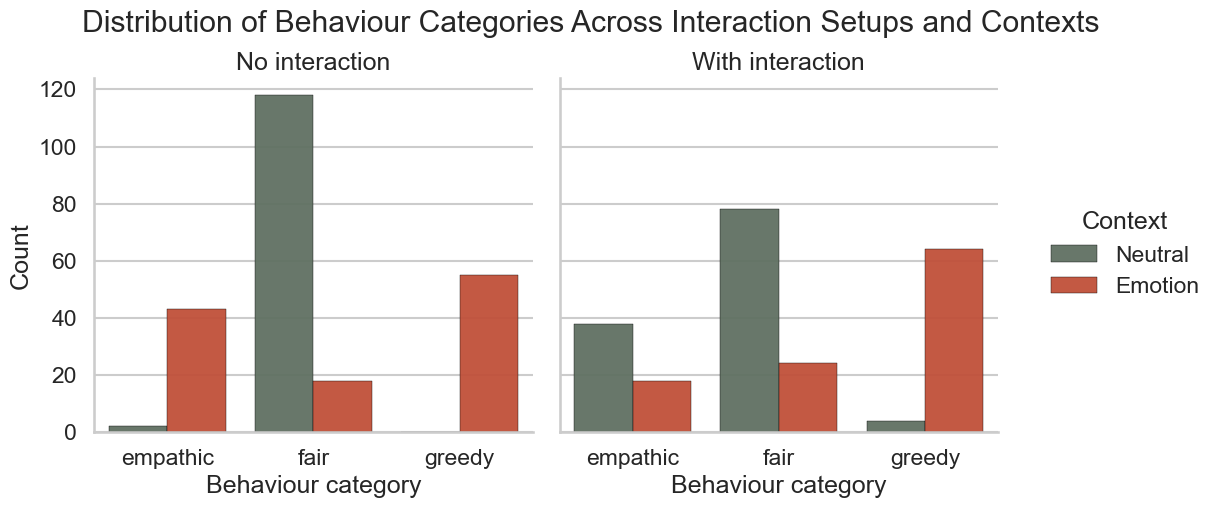

Counts used in plot (same source as contingency table):


behaviour                   empathic  fair  greedy
setup            condition                        
No interaction   Neutral           2   118       0
                 Emotion          43    18      55
With interaction Neutral          38    78       4
                 Emotion          18    24      64

Percent of agents by behaviour category within each setup × context:


behaviour                   empathic  fair  greedy
setup            condition                        
No interaction   Neutral         1.7  98.3     0.0
                 Emotion        37.1  15.5    47.4
With interaction Neutral        31.7  65.0     3.3
                 Emotion        17.0  22.6    60.4

In [11]:
cat_order = ['empathic', 'fair', 'greedy']

# Build a complete count table so zeros are explicit and plotting matches contingency tables.
full_index = pd.MultiIndex.from_product(
    [setup_order, condition_order, cat_order],
    names=['setup', 'condition', 'behaviour'],
)
df_category = (
    df.groupby(['setup', 'condition', 'behaviour'])
    .size()
    .rename('count')
    .reindex(full_index, fill_value=0)
    .reset_index()
)

df_category_plot = df_category.assign(
    setup_display=df_category['setup'].map(setup_label_map),
    condition_display=df_category['condition'].map(condition_label_map),
)

palette_map = {COND_EMOTION: '#C84B31', COND_NEUTRAL: '#5F7161'}

g = sns.catplot(
    data=df_category_plot,
    kind='bar',
    x='behaviour',
    y='count',
    hue='condition_display',
    col='setup_display',
    order=cat_order,
    hue_order=condition_display_order,
    col_order=setup_display_order,
    palette=palette_map,
    estimator='sum',
    errorbar=None,
    height=5,
    aspect=1.05,
    dodge=True,
    saturation=0.9,
    edgecolor='black',
    linewidth=0.3,
    alpha=0.95,
    legend=True,
    native_scale=False,
    orient='v',
)
g.set_axis_labels('Behaviour category', 'Count')
g.set_titles('{col_name}')
if g._legend is not None:
    g._legend.set_title('Context')
g.figure.suptitle('Distribution of Behaviour Categories Across Interaction Setups and Contexts', y=1.03)
plt.show()

full_setup_condition_index = pd.MultiIndex.from_product(
    [setup_order, condition_order],
    names=['setup', 'condition'],
)
count_table = (
    df_category
    .pivot_table(
        index=['setup', 'condition'],
        columns='behaviour',
        values='count',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(index=full_setup_condition_index)
    .reindex(columns=cat_order)
    .astype(int)
)

pct_table = count_table.div(count_table.sum(axis=1), axis=0) * 100.0
pct_table = pct_table.round(1)

print('Counts used in plot (same source as contingency table):')
display(relabel_table_axes(count_table))

print('Percent of agents by behaviour category within each setup × context:')
display(relabel_table_axes(pct_table))


In [12]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
g.figure.savefig(ARTIFACTS_DIR / "behaviour_category_distribution.png", dpi=300, bbox_inches="tight")

### Fisher Tests by Setup

**What this does**:
- Fisher exact tests (descriptive small-sample contingency check) within each setup
- reports Cramer's V as an effect size for the contingency table

**Why needed**: category-level behaviour shifts can be inspected directly from contingency tables.

**Result / interpretation**:
- Fisher p-values summarize whether behaviour-category composition differs between neutral and emotional contexts within each setup
- Cramer's V summarizes strength of association (0 = no association, larger values = stronger association)

In [13]:
# cramers_v is defined in analysis_utils.py

for setup in setup_order:
    ctab = pd.crosstab(
        df[df['setup'] == setup]['condition'],
        df[df['setup'] == setup]['behaviour']
    ).reindex(index=condition_order, columns=cat_order, fill_value=0)

    ctab_display = ctab.copy()
    ctab_display.index = [condition_label_map[value] for value in ctab_display.index]

    print(f'\n{setup_label_map[setup]} contingency table')
    display(ctab_display)

    try:
        fres = fisher_exact(ctab.to_numpy())
        p_f = float(fres.pvalue) if hasattr(fres, 'pvalue') else float(fres[1])
        v = cramers_v(ctab)
        print('Fisher p-value:', p_f, '->', decision_text(p_f))
        print(f"Cramer's V: {v:.4f}")
    except Exception:
        print('Fisher RxC not available in this SciPy build for this table shape.')
        v = cramers_v(ctab)
        print(f"Cramer's V: {v:.4f}")



No interaction contingency table


behaviour,empathic,fair,greedy
Neutral,2,118,0
Emotion,43,18,55


Fisher p-value: 0.0001 -> significant
Cramer's V: 0.8383

With interaction contingency table


behaviour,empathic,fair,greedy
Neutral,38,78,4
Emotion,18,24,64


Fisher p-value: 0.0001 -> significant
Cramer's V: 0.6245


## 6.2.3 Cross-Model Comparison

### Boxplot

**What this does**: plots run-level mean $g_k$ by model, faceted by setup and colored by condition.

**Why needed**: visualizes model spread and contextual shifts at run-level.

**Result / interpretation**: overlap vs separation informs expected significance in model tests.

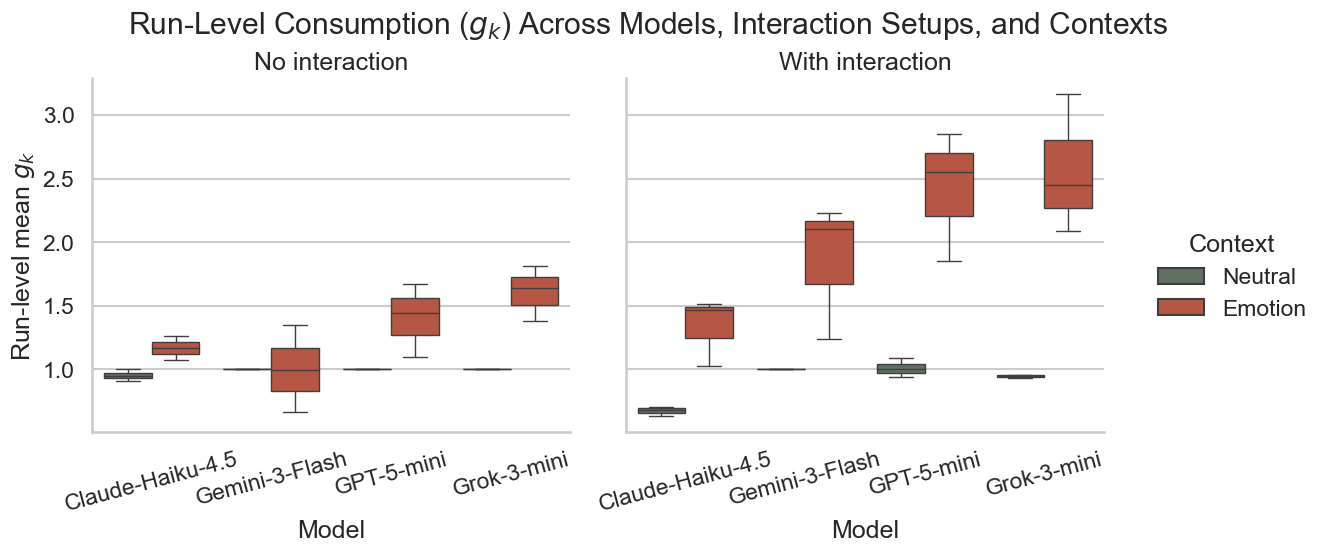

In [14]:
# model_label_map is defined in the path-setup cell above.
plot_run = run2.copy()
plot_run['model_label'] = plot_run['model'].map(model_label_map).fillna(plot_run['model'])
plot_run['setup_display'] = plot_run['setup'].map(setup_label_map)
plot_run['condition_display'] = plot_run['condition'].map(condition_label_map)

g = sns.catplot(
    data=plot_run,
    kind='box',
    x='model_label', y='mean_gk', hue='condition_display', col='setup_display',
    palette=[palette_map[COND_NEUTRAL], palette_map[COND_EMOTION]],
    hue_order=condition_display_order,
    col_order=setup_display_order,
    height=5, aspect=1.15
)
g.set_axis_labels('Model', r'Run-level mean $g_k$')
g.set_titles('{col_name}')
if g._legend is not None:
    g._legend.set_title('Context')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=15)
g.figure.suptitle(r'Run-Level Consumption ($g_k$) Across Models, Interaction Setups, and Contexts', y=1.03)
plt.show()


In [15]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
g.figure.savefig(ARTIFACTS_DIR / "run_level_consumption_boxplot.png", dpi=300, bbox_inches="tight")

### Model Tests (ANOVA or Kruskal-Wallis, adaptive)

**What this does**:
- for each setup x condition cell, checks assumptions and selects ANOVA or Kruskal-Wallis

**Why needed**: model-comparison assumptions can differ by cell.

**Result / interpretation**:
- significant p-value means model architectures differ in that specific setup/context cell

In [ ]:
# kruskal_epsilon_squared, anova_eta_squared, group_sd,
# cohens_d_independent, and format_p are defined in analysis_utils.py

summary_rows = []
tukey_rows = []

for setup in setup_order:
    for cond in condition_order:
        sub = run2[(run2['setup'] == setup) & (run2['condition'] == cond)]

        if sub.empty or sub['model'].nunique() < 2:
            summary_rows.append({
                'setup': setup, 'condition': cond, 'test': 'NA',
                'F': np.nan, 'H': np.nan, 'p': np.nan,
                'eta_sq': np.nan, 'epsilon_sq': np.nan,
                'df_between': np.nan, 'df_within': np.nan,
                'decision': 'insufficient data'
            })
            continue

        grouped = list(sub.groupby('model'))
        labels = [m for m, _ in grouped]
        groups = [g['mean_gk'].to_numpy() for _, g in grouped]
        group_means = {m: float(g['mean_gk'].mean()) for m, g in grouped}
        group_sds = {m: group_sd(g['mean_gk'].to_numpy()) for m, g in grouped}
        group_values = {m: g['mean_gk'].to_numpy() for m, g in grouped}

        shapiro_ps = []
        for _, g in grouped:
            vals = g['mean_gk'].to_numpy()
            if len(vals) >= 3 and np.ptp(vals) > 0:
                _, psh = shapiro(vals)
                shapiro_ps.append(float(psh))

        _, p_lev = levene(*groups, center='median')
        all_normal = (len(shapiro_ps) > 0) and all(p >= 0.05 for p in shapiro_ps)
        homosked = float(p_lev) >= 0.05

        if all_normal and homosked:
            test_name = 'ANOVA'
            f_stat, p_val = f_oneway(*groups)
            f_stat = float(f_stat)
            p_val = float(p_val)
            eta_sq = anova_eta_squared(groups)
            k = len(groups)
            n_total = int(sum(len(g) for g in groups))
            df_between = k - 1
            df_within = n_total - k

            summary_rows.append({
                'setup': setup,
                'condition': cond,
                'test': test_name,
                'F': f_stat,
                'H': np.nan,
                'p': p_val,
                'eta_sq': eta_sq,
                'epsilon_sq': np.nan,
                'df_between': df_between,
                'df_within': df_within,
                'decision': decision_text(p_val),
            })

            if p_val < alpha:
                tukey_res = tukey_hsd(*groups)
                sig_pairs = []
                for i in range(len(labels)):
                    for j in range(i + 1, len(labels)):
                        p_adj = float(tukey_res.pvalue[i, j])
                        mean_i = group_means[labels[i]]
                        mean_j = group_means[labels[j]]
                        if p_adj < alpha:
                            higher = labels[i] if mean_i > mean_j else labels[j]
                            lower = labels[j] if mean_i > mean_j else labels[i]
                            delta = abs(mean_i - mean_j)
                            d_val = abs(cohens_d_independent(group_values[higher], group_values[lower]))
                            pair_row = {
                                'setup': setup,
                                'condition': cond,
                                'higher_model': higher,
                                'lower_model': lower,
                                'M_higher': group_means[higher],
                                'SD_higher': group_sds[higher],
                                'M_lower': group_means[lower],
                                'SD_lower': group_sds[lower],
                                'Delta': delta,
                                'p_adj': p_adj,
                                'p_text': format_p(p_adj),
                                'd': d_val,
                            }
                            sig_pairs.append(pair_row)
                            tukey_rows.append(pair_row)

                if sig_pairs:
                    print('Post-hoc comparisons (Tukey HSD): significant pairs were added to the Tukey summary table below.')
                else:
                    print('Post-hoc comparisons (Tukey HSD) found no significant pairwise differences after adjustment.')
        else:
            test_name = 'Kruskal-Wallis'
            h_stat, p_val = kruskal(*groups)
            epsilon_sq = kruskal_epsilon_squared(h_stat, groups)
            summary_rows.append({
                'setup': setup,
                'condition': cond,
                'test': test_name,
                'F': np.nan,
                'H': float(h_stat),
                'p': float(p_val),
                'eta_sq': np.nan,
                'epsilon_sq': epsilon_sq,
                'df_between': np.nan,
                'df_within': np.nan,
                'decision': decision_text(float(p_val)),
            })

summary_df = pd.DataFrame(summary_rows)
display(apply_display_labels(summary_df).round(4))
summary_df.to_csv(ARTIFACTS_DIR / 'gk_anova_kruskal_summary.csv', index=False)

if tukey_rows:
    
    tukey_df = pd.DataFrame(tukey_rows)
    tukey_df = tukey_df.sort_values(['setup', 'condition', 'p_adj', 'higher_model', 'lower_model']).reset_index(drop=True)
    tukey_df_display = apply_display_labels(tukey_df)
    tukey_df_display['higher_model'] = tukey_df_display['higher_model'].map(model_label_map).fillna(tukey_df_display['higher_model'])
    tukey_df_display['lower_model'] = tukey_df_display['lower_model'].map(model_label_map).fillna(tukey_df_display['lower_model'])
    display(
        tukey_df_display[[
            'setup', 'condition',
            'higher_model', 'lower_model',
            'M_higher', 'SD_higher',
            'M_lower', 'SD_lower',
            'Delta', 'p_adj', 'p_text', 'd',
        ]].round(4)
    )
    tukey_df_display[[
            'setup', 'condition',
            'higher_model', 'lower_model',
            'M_higher', 'SD_higher',
            'M_lower', 'SD_lower',
            'Delta', 'p_adj', 'p_text', 'd',
        ]].round(4).to_csv(ARTIFACTS_DIR / 'gk_tukey_pairwise_comparisons.csv', index=False)
else:
    print('No significant Tukey pairwise differences to tabulate at alpha=0.05.')


Post-hoc comparisons (Tukey HSD): significant pairs were added to the Tukey summary table below.
Post-hoc comparisons (Tukey HSD) found no significant pairwise differences after adjustment.


,setup,condition,test,F,H,p,eta_sq,epsilon_sq,df_between,df_within,decision
0,No interaction,Neutral,ANOVA,3.2131,NaN,0.0830,0.5465,NaN,3,8,not significant
1,No interaction,Emotion,ANOVA,3.3196,NaN,0.0776,0.5545,NaN,3,8,not significant
2,With interaction,Neutral,ANOVA,42.3095,NaN,0.0000,0.9407,NaN,3,8,significant
3,With interaction,Emotion,ANOVA,4.0912,NaN,0.0493,0.6054,NaN,3,8,significant


,setup,condition,higher_model,lower_model,M_higher,SD_higher,M_lower,SD_lower,Delta,p_adj,p_text,d
0,With interaction,Neutral,GPT-5-mini,Claude-Haiku-4.5,1.0099,0.0754,0.6751,0.0338,0.3348,0.0000,p < 0.001,5.7343
1,With interaction,Neutral,Gemini-3-Flash,Claude-Haiku-4.5,1.0000,0.0000,0.6751,0.0338,0.3249,0.0001,p < 0.001,13.5991
2,With interaction,Neutral,Grok-3-mini,Claude-Haiku-4.5,0.9467,0.0153,0.6751,0.0338,0.2716,0.0002,p < 0.001,10.3571


In [17]:
# Reference-group comparison tables: each setup x condition shows other models vs Claude
# Uses a helper from analysis_utils.py to keep this cell analysis-focused.

if tukey_rows:
    tukey_df_full = pd.DataFrame(tukey_rows)
    reference_model = 'claude-haiku-4-5-20251001'
    preferred_model_order = [
        model_label_map.get('claude-haiku-4-5-20251001', 'Claude-Haiku'),
        model_label_map.get('gemini-3-flash-preview', 'Gemini-Flash'),
        model_label_map.get('gpt-5-mini', 'GPT-5-mini'),
        model_label_map.get('grok-3-mini-fast-beta', 'Grok-3-mini'),
    ]

    for setup in setup_order:
        for cond in condition_order:
            subset = tukey_df_full[
                (tukey_df_full['setup'] == setup)
                & (tukey_df_full['condition'] == cond)
            ]
            if subset.empty:
                continue

            ref_table = build_reference_vs_model_table(
                pairwise_df=subset,
                reference_model=reference_model,
                model_label_map=model_label_map,
                preferred_order=preferred_model_order,
            )

            if ref_table.empty:
                continue

            print(f'\n=== {setup_label_map[setup]} | {condition_label_map[cond]} ===')
            display(ref_table.round(3))
            ref_table.to_csv(ARTIFACTS_DIR / f'tukey_hsd_reference_comparison_{setup}_{cond}.csv', index=False)
else:
    print('No Tukey HSD results available to compute reference-group comparison tables.')



=== With interaction | Neutral ===


,Model,Mean g_k,Delta vs Claude,p vs Claude,Cohen's d vs Claude
0,Claude-Haiku-4.5,0.675,-,-,-
1,Gemini-3-Flash,1.000,+0.32,<0.001,13.60
2,GPT-5-mini,1.010,+0.33,<0.001,5.73
3,Grok-3-mini,0.947,+0.27,<0.001,10.36


## 6.2.4 Measuring Position Effect: $PPI_k$ vs $g_k$

### Cell 9A - Correlations by Setup and Context

**What this does**: computes Spearman and Pearson correlations for each setup x condition cell.

**Why needed**: separates monotonic and linear association evidence for position effect.

**Result / interpretation**: significant correlation means structural privilege is associated with consumption behavior.

In [18]:
# spearman_summary is defined in analysis_utils.py

corr_rows = []

for setup, cond in [
    ('game_only', 'neutral'),
    ('game_only', 'emotional'),
    ('with_pregame', 'neutral'),
    ('with_pregame', 'emotional'),
]:
    sub = df[(df['setup'] == setup) & (df['condition'] == cond)]
    setup_label = setup_label_map[setup]
    cond_label = condition_label_map[cond]
    corr_rows.append(
        spearman_summary(
            sub,
            {'Setup × Context': f'{setup_label}, {cond_label}'},
        )
    )

for cond in condition_order:
    sub = df[df['condition'] == cond]
    cond_label = condition_label_map[cond]
    corr_rows.append(
        spearman_summary(
            sub,
            {'Setup × Context': f'Combined {cond_label}'},
        )
    )

corr_table = pd.DataFrame(corr_rows)
corr_table['ρ'] = corr_table['ρ'].round(3)
corr_table['r²'] = corr_table['r²'].round(3)
display(corr_table[[
    'Setup × Context', 'ρ', 'p_text', 'n', 'r²', '95% CI', 'decision'
    ]].rename(columns={'p_text': 'p'}))

corr_table.to_csv(ARTIFACTS_DIR / 'gk_spearman_correlations.csv', index=False)

,Setup × Context,ρ,p,n,r²,95% CI,decision
0,"No interaction, Neutral",0.115,.211,120,0.013,"[-0.066, 0.288]",not significant
1,"No interaction, Emotion",0.241,.009,116,0.058,"[0.061, 0.405]",significant
2,"With interaction, Neutral",0.002,.984,120,0.000,"[-0.177, 0.181]",not significant
3,"With interaction, Emotion",0.241,.013,106,0.058,"[0.053, 0.413]",significant
4,Combined Neutral,0.005,.942,240,0.000,"[-0.122, 0.131]",not significant
5,Combined Emotion,0.197,.003,222,0.039,"[0.067, 0.320]",significant


### Quadrant Analysis and Scatter Plot

**What this does**:
- classifies each turn into 4 quadrants
- displays quadrant counts by setup x condition
- draws scatter with reference lines at $PPI_k=1$ and $g_k=1$

**Why needed**: helps separate opportunistic vs constrained behavior patterns.

**Result / interpretation**: dominant quadrants indicate which behaviour mode is most common.

quadrant                    Opportunistic greed  Forced greed  \
setup            condition                                      
No interaction   Emotion                     53             2   
                 Neutral                      0             0   
With interaction Emotion                     52            12   
                 Neutral                      4             0   

quadrant                    True generosity  Symbolic generosity  
setup            condition                                        
No interaction   Emotion                 45                   16  
                 Neutral                109                   11  
With interaction Emotion                 23                   19  
                 Neutral                109                    7

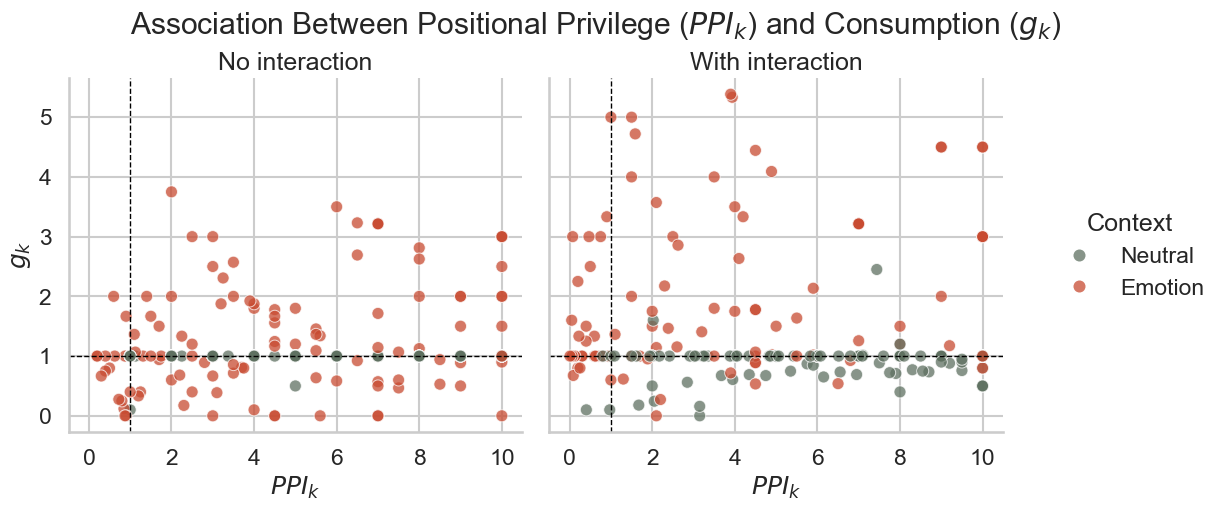

Interpretation guide:
- More points in Opportunistic greed: high privilege and high taking.
- More points in Forced greed: high taking under low privilege.
- More points in True/Symbolic generosity: lower taking behavior.


In [19]:
quad_labels = ['Opportunistic greed', 'Forced greed', 'True generosity', 'Symbolic generosity']
tmp = df.copy()
tmp['quadrant'] = np.select(
    [
        (tmp['ppi_k'] > 1) & (tmp['g_k'] > 1),
        (tmp['ppi_k'] <= 1) & (tmp['g_k'] > 1),
        (tmp['ppi_k'] > 1) & (tmp['g_k'] <= 1),
        (tmp['ppi_k'] <= 1) & (tmp['g_k'] <= 1),
    ],
    quad_labels,
    default='Unclassified'
)

tmp['setup_display'] = tmp['setup'].map(setup_label_map)
tmp['condition_display'] = tmp['condition'].map(condition_label_map)

qtab = pd.crosstab(
    [tmp['setup'], tmp['condition']],
    tmp['quadrant']
    ).reindex(columns=quad_labels, fill_value=0)
display(relabel_table_axes(qtab))

g = sns.relplot(
    data=tmp,
    kind='scatter',
    x='ppi_k', y='g_k',
    hue='condition_display', col='setup_display',
    hue_order=condition_display_order,
    col_order=setup_display_order,
    palette=[palette_map[COND_NEUTRAL], palette_map[COND_EMOTION]],
    alpha=0.75, s=75, height=5, aspect=1.05
)
for ax in g.axes.flat:
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1)
    ax.axhline(1.0, color='black', linestyle='--', linewidth=1)
g.set_axis_labels(r'$PPI_k$', r'$g_k$')
g.set_titles('{col_name}')
if g._legend is not None:
    g._legend.set_title('Context')
g.figure.suptitle(r'Association Between Positional Privilege ($PPI_k$) and Consumption ($g_k$)', y=1.03)
plt.show()

print('Interpretation guide:')
print('- More points in Opportunistic greed: high privilege and high taking.')
print('- More points in Forced greed: high taking under low privilege.')
print('- More points in True/Symbolic generosity: lower taking behavior.')


In [20]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
g.figure.savefig(ARTIFACTS_DIR / "ppi_vs_gk_scatter.png", dpi=300, bbox_inches="tight")

### Heatmap: Resource Depletion by Turn Position and Model

**What this does**: displays consumption ($g_k$) intensity as a heatmap across models and turn positions, showing depletion patterns.

**Why needed**: reveals whether certain models consume more at early (low $PPI_k$) or late (high $PPI_k$) turns, and how context affects depletion.

**Result / interpretation**: darker cells indicate higher consumption; compare patterns across setup and condition to see if emotional context or pregame discussion shifts when agents take resources.

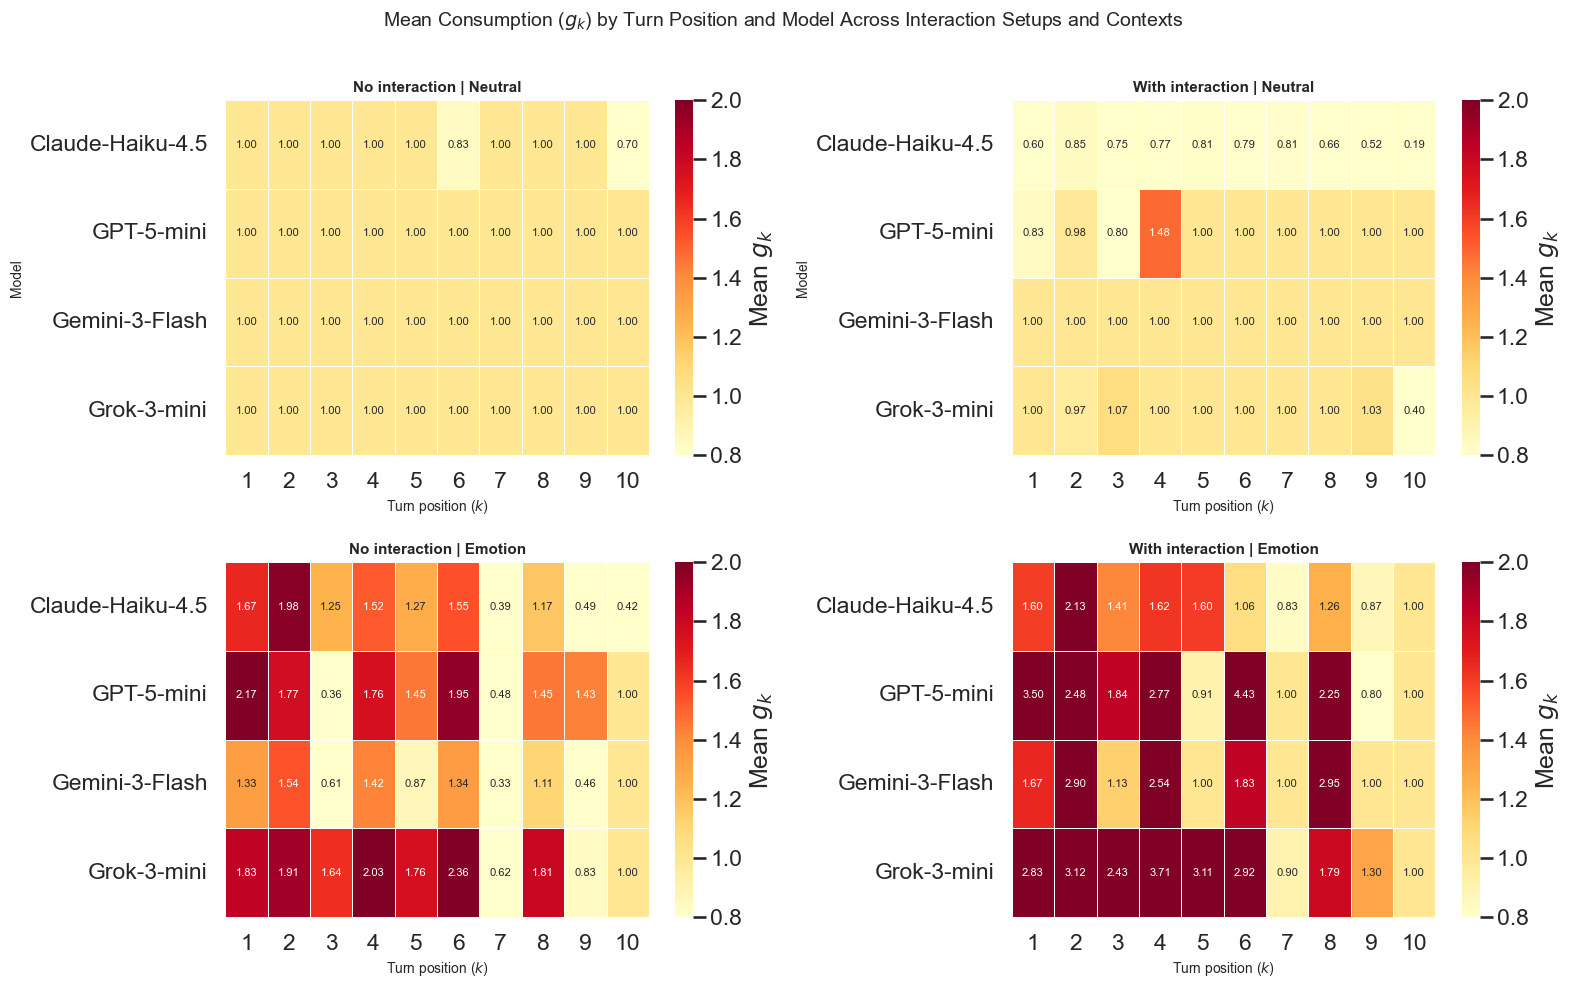

In [21]:
# Prepare data for heatmap: average g_k by model, position_k (turn order), setup, and condition
heatmap_data = (
    df.groupby(['setup', 'condition', 'model', 'position_k'], as_index=False)
    .agg(mean_g_k=('g_k', 'mean'), count=('g_k', 'size'))
)

# Create heatmaps for each setup x condition combination
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    r'Mean Consumption ($g_k$) by Turn Position and Model Across Interaction Setups and Contexts',
    fontsize=14,
    y=0.995
    )

for setup_idx, setup in enumerate(setup_order):
    for cond_idx, cond in enumerate(condition_order):
        ax = axes[cond_idx, setup_idx]
        setup_title = setup_label_map[setup]
        cond_title = condition_label_map[cond]

        # Filter data for this setup x condition
        subset = heatmap_data[(heatmap_data['setup'] == setup) & (heatmap_data['condition'] == cond)]

        if subset.empty:
            ax.text(
                0.5,
                0.5,
                f'{setup_title}\n{cond_title}\n(no data)',
                ha='center',
                va='center',
                transform=ax.transAxes,
            )
            ax.set_title(f'{setup_title} | {cond_title}', fontsize=11)
            ax.axis('off')
            continue

        # Pivot to heatmap format: rows=model (Y-axis), cols=position_k (X-axis), values=mean_g_k
        hmap = subset.pivot_table(
            index='model',
            columns='position_k',
            values='mean_g_k',
            aggfunc='mean',
        )

        # Map model names to labels for readability
        hmap.index = [model_label_map.get(m, m) for m in hmap.index]
        hmap = hmap.sort_index()

        # Create heatmap
        sns.heatmap(
            hmap,
            ax=ax,
            cmap='YlOrRd',
            cbar_kws={'label': r'Mean $g_k$'},
            vmin=0.8,
            vmax=2.0,
            linewidths=0.5,
            linecolor='white',
            annot=True,
            fmt='.2f',
            annot_kws={'size': 8},
        )
        ax.set_title(f'{setup_title} | {cond_title}', fontsize=11, fontweight='bold')
        ax.set_xlabel(r'Turn position ($k$)', fontsize=10)
        ax.set_ylabel('Model' if cond_idx == 0 else '', fontsize=10)

plt.tight_layout()
plt.show()


In [22]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(ARTIFACTS_DIR / "mean_gk_heatmap_by_position.png", dpi=300, bbox_inches="tight")

## 6.2.5 Gini-Based Fairness Analysis

### Load Run-Level Gini Scores

**What this does**: loads one Gini coefficient per run from the setup-specific `scores` folders and reconstructs run metadata from the score filenames.

**Why needed**: Gini summarizes inequality in allocation, where lower values indicate more equal and therefore fairer outcomes.

**Result / interpretation**: in this dataset, the `v1` / `v2` / `v3` suffixes correspond to three replicate runs, so your `1st`, `2nd`, and `3rd` values are run replicates rather than within-run time steps.

In [23]:
# SCORE_SOURCES and model_label_map are defined in the path-setup cell.
# Data loading is handled by load_gini_scores in analysis_utils.py.
gini_df = load_gini_scores(SCORE_SOURCES, model_label_map)

display(apply_display_labels(gini_df.head()))

gini_summary = (
    gini_df.groupby(['setup', 'condition', 'model_label'], as_index=False)
    .agg(
        n=('gini', 'size'),
        mean_gini=('gini', 'mean'),
        sd_gini=('gini', 'std'),
    )
)

# Format mean±sd without passing a callable as an argument.
sd_clean = gini_summary['sd_gini'].fillna(0.0)
mean_str = [f'{v:.4f}' for v in gini_summary['mean_gini']]
sd_str   = [f'{v:.4f}' for v in sd_clean]
gini_summary['mean±std'] = [f'{m} ± {s}' for m, s in zip(mean_str, sd_str)]

display(apply_display_labels(gini_summary).round(4))

gini_repl = (
    gini_df.pivot_table(
        index=['setup', 'condition', 'model_label'],
        columns='version',
        values='gini',
        aggfunc='mean',
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

if {'v1', 'v2', 'v3'}.issubset(gini_repl.columns):
    row_means = gini_repl[['v1', 'v2', 'v3']].mean(axis=1)
    row_stds  = gini_repl[['v1', 'v2', 'v3']].std(axis=1, ddof=1)
    mean_str = [f'{v:.4f}' for v in row_means]
    std_str  = [f'{v:.4f}' for v in row_stds]
    gini_repl['mean±std'] = [f'{m} ± {s}' for m, s in zip(mean_str, std_str)]

display(apply_display_labels(gini_repl).round(4))

print('Interpretation guide: lower Gini = more equal/fair, higher Gini = more unequal/greedy.')


game_only: 24 score files
with_pregame: 24 score files


,setup,run_id,model,model_label,condition,version,replicate,gini
0,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T09...,claude-haiku-4-5-20251001,Claude-Haiku-4.5,Emotion,v1,1,0.4330
1,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T09...,claude-haiku-4-5-20251001,Claude-Haiku-4.5,Emotion,v2,2,0.4516
2,No interaction,run_0001_claude-haiku-4-5-20251001_20260318T09...,claude-haiku-4-5-20251001,Claude-Haiku-4.5,Emotion,v3,3,0.2950
3,No interaction,run_0001_gpt-5-mini_20260318T090925Z_emotional_v1,gpt-5-mini,GPT-5-mini,Emotion,v1,1,0.5135
4,No interaction,run_0001_gpt-5-mini_20260318T091249Z_emotional_v2,gpt-5-mini,GPT-5-mini,Emotion,v2,2,0.4320


,setup,condition,model_label,n,mean_gini,sd_gini,mean±std
0,No interaction,Emotion,Claude-Haiku-4.5,3,0.3932,0.0856,0.3932 ± 0.0856
1,No interaction,Emotion,GPT-5-mini,3,0.4825,0.0441,0.4825 ± 0.0441
2,No interaction,Emotion,Gemini-3-Flash,3,0.4592,0.0570,0.4592 ± 0.0570
3,No interaction,Emotion,Grok-3-mini,3,0.4833,0.0402,0.4833 ± 0.0402
4,No interaction,Neutral,Claude-Haiku-4.5,3,0.0547,0.0479,0.0547 ± 0.0479
5,No interaction,Neutral,GPT-5-mini,3,0.0000,0.0000,0.0000 ± 0.0000
6,No interaction,Neutral,Gemini-3-Flash,3,0.0000,0.0000,0.0000 ± 0.0000
7,No interaction,Neutral,Grok-3-mini,3,0.0000,0.0000,0.0000 ± 0.0000
8,With interaction,Emotion,Claude-Haiku-4.5,3,0.3150,0.1739,0.3150 ± 0.1739
9,With interaction,Emotion,GPT-5-mini,3,0.6091,0.0563,0.6091 ± 0.0563


,setup,condition,model_label,v1,v2,v3,mean±std
0,No interaction,Emotion,Claude-Haiku-4.5,0.4330,0.4516,0.2950,0.3932 ± 0.0856
1,No interaction,Emotion,GPT-5-mini,0.5135,0.4320,0.5020,0.4825 ± 0.0441
2,No interaction,Emotion,Gemini-3-Flash,0.5137,0.4000,0.4640,0.4592 ± 0.0570
3,No interaction,Emotion,Grok-3-mini,0.5280,0.4720,0.4500,0.4833 ± 0.0402
4,No interaction,Neutral,Claude-Haiku-4.5,0.0750,0.0890,0.0000,0.0547 ± 0.0479
5,No interaction,Neutral,GPT-5-mini,0.0000,0.0000,0.0000,0.0000 ± 0.0000
6,No interaction,Neutral,Gemini-3-Flash,0.0000,0.0000,0.0000,0.0000 ± 0.0000
7,No interaction,Neutral,Grok-3-mini,0.0000,0.0000,0.0000,0.0000 ± 0.0000
8,With interaction,Emotion,Claude-Haiku-4.5,0.4620,0.3600,0.1230,0.3150 ± 0.1739
9,With interaction,Emotion,GPT-5-mini,0.5648,0.5900,0.6724,0.6091 ± 0.0563


Interpretation guide: lower Gini = more equal/fair, higher Gini = more unequal/greedy.


In [24]:
apply_display_labels(gini_summary)

,setup,condition,model_label,n,mean_gini,sd_gini,mean±std
0,No interaction,Emotion,Claude-Haiku-4.5,3,0.393200,0.085551,0.3932 ± 0.0856
1,No interaction,Emotion,GPT-5-mini,3,0.482500,0.044111,0.4825 ± 0.0441
2,No interaction,Emotion,Gemini-3-Flash,3,0.459233,0.057000,0.4592 ± 0.0570
3,No interaction,Emotion,Grok-3-mini,3,0.483333,0.040216,0.4833 ± 0.0402
4,No interaction,Neutral,Claude-Haiku-4.5,3,0.054667,0.047857,0.0547 ± 0.0479
5,No interaction,Neutral,GPT-5-mini,3,0.000000,0.000000,0.0000 ± 0.0000
6,No interaction,Neutral,Gemini-3-Flash,3,0.000000,0.000000,0.0000 ± 0.0000
7,No interaction,Neutral,Grok-3-mini,3,0.000000,0.000000,0.0000 ± 0.0000
8,With interaction,Emotion,Claude-Haiku-4.5,3,0.315000,0.173922,0.3150 ± 0.1739
9,With interaction,Emotion,GPT-5-mini,3,0.609067,0.056277,0.6091 ± 0.0563


### Bar Chart by Model

**What this does**: plots mean run-level Gini per model, split by setup and condition, with standard-deviation error bars across replicates.

**Why needed**: this gives a faster comparison of which models produce more unequal outcomes before reading the inferential tables.

**Result / interpretation**: taller bars indicate higher inequality; wider error bars indicate more variation across replicates.

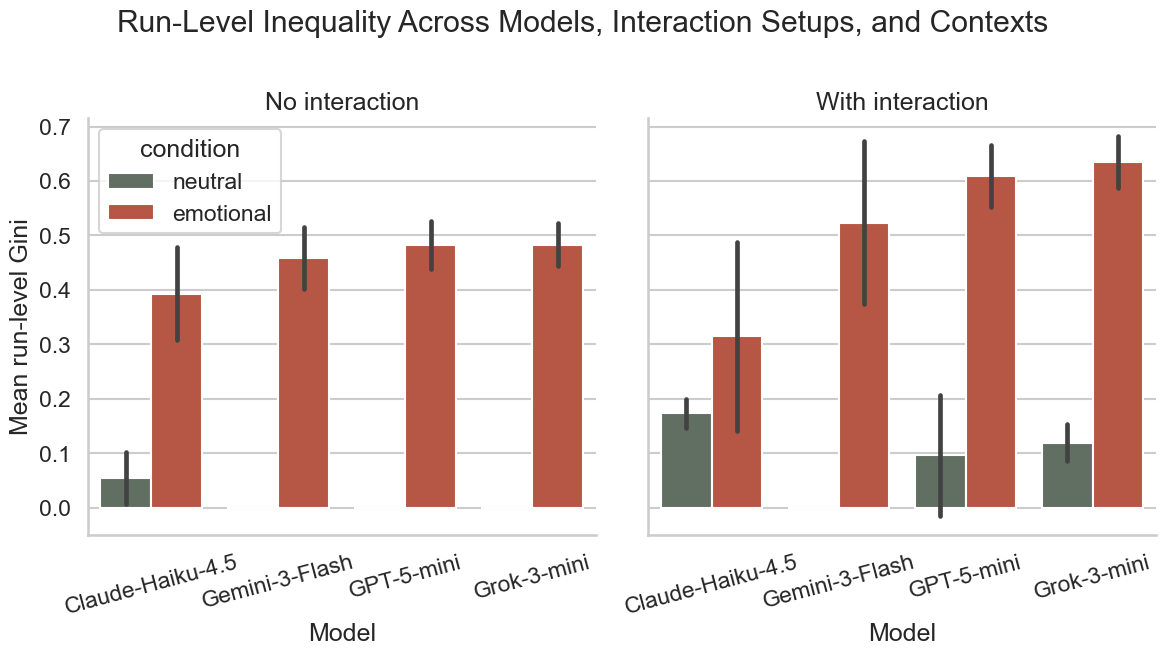

In [35]:
gini_model_order = [
    label for label in [
        'Claude-Haiku-4.5',
        'Gemini-3-Flash',
        'GPT-5-mini',
        'Grok-3-mini',
    ]
    if label in set(gini_df['model_label'])
]

gini_plot = gini_df.assign(
    setup_display=gini_df['setup'].map(setup_label_map),
)

g = sns.catplot(
    data=gini_plot,
    kind='bar',
    x='model_label',
    y='gini',
    hue='condition',
    col='setup_display',
    order=gini_model_order,
    hue_order=condition_order,
    col_order=setup_display_order,
    estimator='mean',
    errorbar='sd',
    palette=['#5F7161', '#C84B31'],
    height=6,
    aspect=1.0,
    legend_out=False,
)
g.set_axis_labels('Model', 'Mean run-level Gini')
g.set_titles('{col_name}')
if g._legend is not None:
    g._legend.set_title('condition')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=15)
g.figure.subplots_adjust(top=0.85)
g.figure.suptitle('Run-Level Inequality Across Models, Interaction Setups, and Contexts', y=1.03)
plt.show()


In [26]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
g.figure.savefig(ARTIFACTS_DIR / "run_level_gini_barplot.png", dpi=300, bbox_inches="tight")

In [27]:
# Save Gini replicate summary to artifacts
gini_repl.round(4).to_csv(ARTIFACTS_DIR / 'gini_replicate_summary.csv', index=False)

In [28]:
# summarize_median_iqr, safe_wilcoxon, and build_gini_row
# are defined in analysis_utils.py

gini_needed_cols = [
    ('game_only', 'neutral'),
    ('game_only', 'emotional'),
    ('with_pregame', 'neutral'),
    ('with_pregame', 'emotional'),
]

gini_blocks = gini_df.pivot_table(
    index=['model', 'version'],
    columns=['setup', 'condition'],
    values='gini',
    aggfunc='mean',
)
gini_has_all_cols = all(c in gini_blocks.columns for c in gini_needed_cols)
gini_complete = gini_blocks.dropna(subset=gini_needed_cols) if gini_has_all_cols else pd.DataFrame()

if gini_has_all_cols and len(gini_complete) > 0:
    gini_go_neu = gini_complete[('game_only', 'neutral')]
    gini_go_emo = gini_complete[('game_only', 'emotional')]
    gini_pg_neu = gini_complete[('with_pregame', 'neutral')]
    gini_pg_emo = gini_complete[('with_pregame', 'emotional')]

    gini_emotion_game_only    = gini_go_emo - gini_go_neu
    gini_emotion_with_pregame = gini_pg_emo - gini_pg_neu
    gini_setup_neutral        = gini_pg_neu - gini_go_neu
    gini_setup_emotional      = gini_pg_emo - gini_go_emo

    gini_main_emotion  = 0.5 * (gini_emotion_game_only + gini_emotion_with_pregame)
    gini_main_setup    = 0.5 * (gini_setup_neutral + gini_setup_emotional)
    gini_interaction   = gini_emotion_with_pregame - gini_emotion_game_only

    gini_overall_emotional  = 0.5 * (gini_go_emo + gini_pg_emo)
    gini_overall_neutral    = 0.5 * (gini_go_neu + gini_pg_neu)
    gini_overall_with_pregame = 0.5 * (gini_pg_neu + gini_pg_emo)
    gini_overall_game_only  = 0.5 * (gini_go_neu + gini_go_emo)

    gini_res = pd.DataFrame([
        build_gini_row(
            f'Within {SETUP_NO_INTERACTION}: {COND_EMOTION} - {COND_NEUTRAL}',
            COND_EMOTION, COND_NEUTRAL,
            gini_go_emo, gini_go_neu,
            gini_emotion_game_only,
        ),
        build_gini_row(
            f'Within {SETUP_WITH_INTERACTION}: {COND_EMOTION} - {COND_NEUTRAL}',
            COND_EMOTION, COND_NEUTRAL,
            gini_pg_emo, gini_pg_neu,
            gini_emotion_with_pregame,
        ),
        build_gini_row(
            f'Main effect of context ({COND_EMOTION} vs {COND_NEUTRAL})',
            f'{COND_EMOTION} (avg setups)', f'{COND_NEUTRAL} (avg setups)',
            gini_overall_emotional, gini_overall_neutral,
            gini_main_emotion,
        ),
        build_gini_row(
            'Main effect of interaction setup',
            f'{SETUP_WITH_INTERACTION} (avg contexts)', f'{SETUP_NO_INTERACTION} (avg contexts)',
            gini_overall_with_pregame, gini_overall_game_only,
            gini_main_setup,
        ),
        build_gini_row(
            'Interaction (setup × context)',
            f'{COND_EMOTION} effect in {SETUP_WITH_INTERACTION}', f'{COND_EMOTION} effect in {SETUP_NO_INTERACTION}',
            gini_emotion_with_pregame, gini_emotion_game_only,
            gini_interaction,
        ),
    ])

    gini_numeric_cols = [
        'Mean_group_1', 'Mean_group_2',
        'Median_group_1', 'IQR_group_1', 'Median_group_2', 'IQR_group_2',
        'M_diff', 'W', 'z', 'p', 'r',
    ]
    gini_res[gini_numeric_cols] = gini_res[gini_numeric_cols].round(4)
    display(gini_res)
    gini_res.to_csv(ARTIFACTS_DIR / 'gini_statistical_test_summary.csv', index=False)

else:
    print('Not enough complete 2x2 Gini blocks yet for main-effect and interaction inference.')


,Effect,Group_1,Group_2,Mean_group_1,Mean_group_2,Median_group_1,IQR_group_1,Median_group_2,IQR_group_2,M_diff,W,z,p,r,decision_alpha_0.05
0,Within No interaction: Emotion - Neutral,Emotion,Neutral,0.4546,0.0137,0.4578,0.0721,0.0000,0.0000,0.4409,0.0,-3.0594,0.0022,0.8832,significant
1,Within With interaction: Emotion - Neutral,Emotion,Neutral,0.5205,0.0974,0.5724,0.2165,0.1013,0.1603,0.4231,1.0,-2.9810,0.0029,0.8605,significant
2,Main effect of context (Emotion vs Neutral),Emotion (avg setups),Neutral (avg setups),0.4875,0.0555,0.5278,0.1113,0.0506,0.1025,0.4320,0.0,-3.0594,0.0022,0.8832,significant
3,Main effect of interaction setup,With interaction (avg contexts),No interaction (avg contexts),0.3089,0.2341,0.3260,0.1165,0.2435,0.0340,0.0748,7.0,-2.5103,0.0121,0.7247,significant
4,Interaction (setup × context),Emotion effect in With interaction,Emotion effect in No interaction,0.4231,0.4409,0.4927,0.2325,0.4570,0.1142,-0.0178,36.0,-0.2353,0.8139,0.0679,not significant


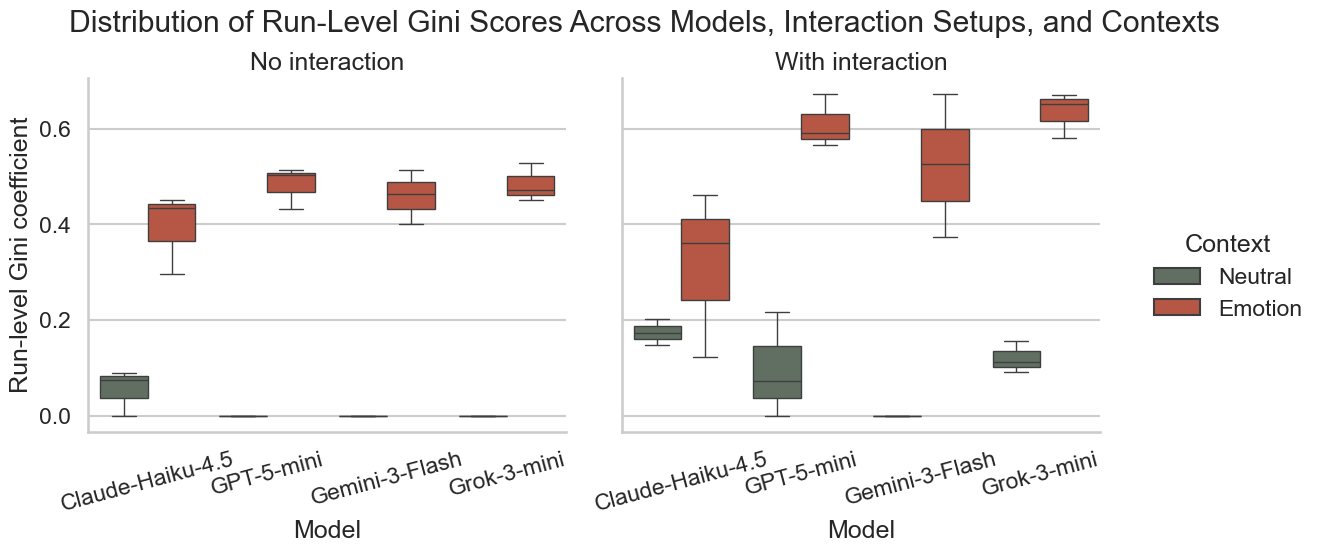

,setup,condition,test,H,p,epsilon_sq,sig,decision
0,No interaction,Neutral,Kruskal-Wallis,6.5455,0.0879,0.4432,ns,not significant
1,No interaction,Emotion,Kruskal-Wallis,2.7949,0.4243,0.0000,ns,not significant
2,With interaction,Neutral,Kruskal-Wallis,6.3901,0.0941,0.4238,ns,not significant
3,With interaction,Emotion,Kruskal-Wallis,5.8718,0.1180,0.3590,ns,not significant


In [29]:
# holm_adjust, p_stars, and kruskal_epsilon_squared
# are defined in analysis_utils.py

gini_box_plot = gini_df.assign(
    setup_display=gini_df['setup'].map(setup_label_map),
    condition_display=gini_df['condition'].map(condition_label_map),
)

g = sns.catplot(
    data=gini_box_plot,
    kind='box',
    x='model_label', y='gini', hue='condition_display', col='setup_display',
    palette=[palette_map[COND_NEUTRAL], palette_map[COND_EMOTION]],
    hue_order=condition_display_order,
    col_order=setup_display_order,
    height=5, aspect=1.15,
    order=sorted(gini_df['model_label'].unique()),
)
g.set_axis_labels('Model', 'Run-level Gini coefficient')
g.set_titles('{col_name}')
if g._legend is not None:
    g._legend.set_title('Context')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=15)
g.figure.suptitle('Distribution of Run-Level Gini Scores Across Models, Interaction Setups, and Contexts', y=1.03)
plt.show()

gini_model_tests = []
gini_pairwise_tests = []

for setup in setup_order:
    for cond in condition_order:
        sub = gini_df[(gini_df['setup'] == setup) & (gini_df['condition'] == cond)]

        groups = []
        labels = []
        for model_label, grp in sub.groupby('model_label'):
            vals = grp['gini'].dropna().to_numpy()
            if len(vals) > 0:
                labels.append(model_label)
                groups.append(vals)

        if len(groups) < 2:
            gini_model_tests.append({
                'setup': setup,
                'condition': cond,
                'test': 'NA',
                'H': np.nan,
                'p': np.nan,
                'epsilon_sq': np.nan,
                'sig': '',
                'decision': 'insufficient data',
            })
            continue

        h_stat, p_value = kruskal(*groups)
        epsilon_sq = kruskal_epsilon_squared(h_stat, groups)
        gini_model_tests.append({
            'setup': setup,
            'condition': cond,
            'test': 'Kruskal-Wallis',
            'H': float(h_stat),
            'p': float(p_value),
            'epsilon_sq': epsilon_sq,
            'sig': p_stars(float(p_value)),
            'decision': decision_text(float(p_value)),
        })

        raw_ps = []
        pair_results = []
        for i, j in combinations(range(len(labels)), 2):
            stat_u, p_u = mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            pair_results.append({
                'setup': setup,
                'condition': cond,
                'model_a': labels[i],
                'model_b': labels[j],
                'u_stat': float(stat_u),
                'raw_p': float(p_u),
            })
            raw_ps.append(float(p_u))

        if pair_results:
            adjusted = holm_adjust(raw_ps)
            for result, adj_p in zip(pair_results, adjusted):
                result['holm_p'] = float(adj_p)
                result['sig'] = p_stars(float(adj_p))
                result['decision_alpha_0.05'] = decision_text(float(adj_p))
                gini_pairwise_tests.append(result)

gini_model_tests_df = pd.DataFrame(gini_model_tests)
display(apply_display_labels(gini_model_tests_df).round(4))

gini_model_tests_df.to_csv(ARTIFACTS_DIR / 'gini_model_comparison_tests.csv', index=False)

In [30]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
g.figure.savefig(ARTIFACTS_DIR / "run_level_gini_boxplot.png", dpi=300, bbox_inches="tight")

In [31]:
if gini_pairwise_tests:
    gini_pairwise_df = pd.DataFrame(gini_pairwise_tests)
    gini_pairwise_df = gini_pairwise_df.sort_values(
        ['setup', 'condition', 'holm_p', 'model_a', 'model_b']
        ).reset_index(drop=True)
    display(apply_display_labels(gini_pairwise_df).round(4))
else:
    print('No pairwise Gini comparisons were generated.')


,setup,condition,model_a,model_b,u_stat,raw_p,holm_p,sig,decision_alpha_0.05
0,No interaction,Emotion,Claude-Haiku-4.5,GPT-5-mini,2.0,0.4000,1.0000,ns,not significant
1,No interaction,Emotion,Claude-Haiku-4.5,Gemini-3-Flash,2.0,0.4000,1.0000,ns,not significant
2,No interaction,Emotion,Claude-Haiku-4.5,Grok-3-mini,1.0,0.2000,1.0000,ns,not significant
3,No interaction,Emotion,GPT-5-mini,Gemini-3-Flash,5.0,1.0000,1.0000,ns,not significant
4,No interaction,Emotion,GPT-5-mini,Grok-3-mini,4.0,1.0000,1.0000,ns,not significant
5,No interaction,Emotion,Gemini-3-Flash,Grok-3-mini,3.0,0.7000,1.0000,ns,not significant
6,No interaction,Neutral,Claude-Haiku-4.5,GPT-5-mini,7.5,0.1967,1.0000,ns,not significant
7,No interaction,Neutral,Claude-Haiku-4.5,Gemini-3-Flash,7.5,0.1967,1.0000,ns,not significant
8,No interaction,Neutral,Claude-Haiku-4.5,Grok-3-mini,7.5,0.1967,1.0000,ns,not significant
9,No interaction,Neutral,GPT-5-mini,Gemini-3-Flash,4.5,1.0000,1.0000,ns,not significant
